# Red Cross detection and classification demo workflow

In [1]:
import os
import json
import glob
from random import shuffle

import cv2
import numpy as np
import torch
from torchmetrics import detection, F1Score
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.engine import DefaultPredictor
from detectron2.engine.defaults import DefaultPredictor
from detectron2.utils.logger import setup_logger
from detectron2.utils.visualizer import Visualizer

import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import rasterio
import pandas as pd

In [2]:
import sys
sys.path.append("../")


from src.datamodule import HouseDataModule
from src.model import HPClassifier
from detect_clip_classify import evaluate_classification_model, clip_image_around_bbox_buffer, load_classification_model
from torchvision.transforms import Compose, Resize, ToTensor, Normalize, ToPILImage

In [3]:
import torch, detectron2

### Load the model

In [4]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(                                                                                                                              
    "ericfrench2015/street_level_building_detection", "model_final.pth"                                                                                    
)                                                                                                                                                          
config_path = hf_hub_download(                                                                                                                             
    "ericfrench2015/street_level_building_detection", "config.yml"                                                                                         
)

cfg = get_cfg()                                                                                                                                            
cfg.merge_from_file(config_path)                                                                                                                           
cfg.MODEL.WEIGHTS = model_path  # Directly use the downloaded model                                                                                        
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"                                                                                          
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Set confidence threshold

In [5]:
predictor = DefaultPredictor(cfg)

### Run inference

In [6]:
# In case we'd like to store our test images with inferences plotted
output_dir = "./output"
inference_image_output = f"{output_dir}/test_inference_images/"
os.makedirs(inference_image_output, exist_ok=True)

#### Generate predictions on an example image

In [7]:
# Random example image
data_dir = "./data/"
fn = "BuildingD-ALBERTANDVERALISTACADEMICCENTER.jpg"

# Example image from mapillary
sequence_id = "Qycm8N0gHbjkBZCtdxMoY3"
data_dir = f"../data/images_new/{sequence_id}/"
fn = "1498749314134807_right.jpg"
# fn = "1498749314134807_left.jpg"


fp = os.path.join(data_dir, fn)



In [8]:
fns = ["1151687366525068_left.jpg", "1498749314134807_left.jpg"]
fps = [os.path.join(data_dir, fn) for fn in fns]

In [9]:
fn = fns[0]

#### Visualize one of the resulting images

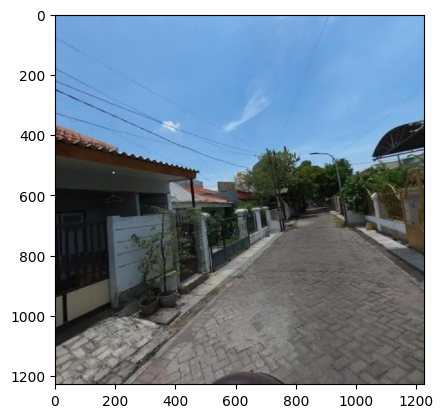

In [10]:
import matplotlib.image as mpimg

# Specify the path to your image
image_path = f'{inference_image_output}/{fn}'

# Load the image using matplotlib.image.imread
img = mpimg.imread(image_path)

# Plot the image using matplotlib.pyplot.imshow
plt.imshow(img)

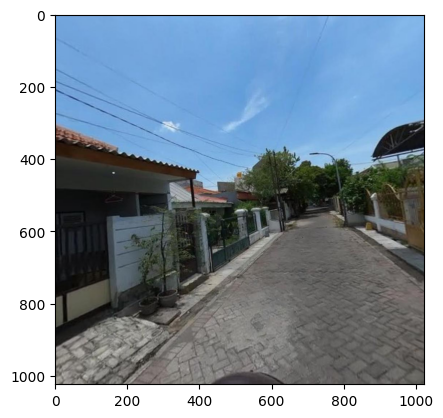

In [11]:
image_path = fps[0]
# Load the image using matplotlib.image.imread
img = mpimg.imread(image_path)

# Plot the image using matplotlib.pyplot.imshow
plt.imshow(img)

In [12]:
# fps = [ '../data/images_new/Qycm8N0gHbjkBZCtdxMoY3/614712470965416_left.jpg']
fps = fps[:2]

In [13]:

side = "right"  # choose which side of the street to process

fps = glob.glob(data_dir + f"*_{side}.jpg")

In [14]:
cumulative_predictions = []

# TODO: Start of iteration over images
for fp in tqdm.tqdm(fps):
    fn = os.path.basename(fp)
    im = cv2.imread(fp)
    outputs = predictor(im)
    v = Visualizer(im[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TEST[0]), scale=1.2)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    pred_image = out.get_image()[:, :, ::-1]
    cv2.imwrite(f"{inference_image_output}{fn.replace('/', '_')}", out.get_image()[:, :, ::-1])

    for box_ind, (bb, sc) in enumerate(zip(outputs["instances"].pred_boxes, outputs["instances"].scores)):
        bbox_data = bb.tolist() 
        clipped_img = clip_image_around_bbox_buffer(im, bbox_data)
        img = torch.tensor(clipped_img.transpose(2,0,1)).to(torch.float32)
        img = ToPILImage()(img)
        transform = Compose([
            Resize((512,512), antialias=True),
            ToTensor(),
            Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        img = transform(img)
        img = img.unsqueeze(0)
        image_clipped_output_dirs = fn.split('/')
        
        clipped_data_dir = f"{inference_image_output}/clips"
        os.makedirs(clipped_data_dir, exist_ok=True)
        
        clipped_fn = f"{fn[:-4]}_{box_ind}.jpg"
        clipped_fp = os.path.join(clipped_data_dir, clipped_fn)
        
        cv2.imwrite(clipped_fp, clipped_img)
    
        # Collecting data to output to predictions.csv
        
        categories = {
            "complete": "incomplete",
            "condition": "good",
            "material": "plaster",
            "security": "unsecured",
            "use": "residential"
        }
        
        image_boxes_categories = {
            "image_name": os.path.join(sequence_id, fn), 
            "boxes": bbox_data, 
            "box_scores": float(sc),
            "complete": categories["complete"], 
            "condition": categories["condition"],
            "material": categories["material"], 
            "security": categories["security"],
            "use": categories["use"], 
            "image_name_clip": clipped_fn,
            # "ground_truth": gt['attributes']
        }
        image_boxes_categories
        
        cumulative_predictions.append(image_boxes_categories)

/opt/miniconda3/envs/hp/lib/python3.10/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 788/788 [18:14<00:00,  1.39s/it]


In [15]:
# end of iteration over images

In [16]:
df_preds = pd.DataFrame(cumulative_predictions)
df_preds.head(20)

,image_name,boxes,box_scores,complete,condition,material,security,use,image_name_clip
0,Qycm8N0gHbjkBZCtdxMoY3/614861100930680_right.jpg,"[10.892929077148438, 135.39138793945312, 302.7...",0.984006,incomplete,good,plaster,unsecured,residential,614861100930680_right_0.jpg
1,Qycm8N0gHbjkBZCtdxMoY3/614861100930680_right.jpg,"[521.7852783203125, 60.71566390991211, 734.635...",0.885767,incomplete,good,plaster,unsecured,residential,614861100930680_right_1.jpg
2,Qycm8N0gHbjkBZCtdxMoY3/614712470965416_right.jpg,"[554.7294311523438, 240.8018341064453, 950.137...",0.925486,incomplete,good,plaster,unsecured,residential,614712470965416_right_0.jpg
3,Qycm8N0gHbjkBZCtdxMoY3/1316182663132269_right.jpg,"[206.79461669921875, 225.26844787597656, 707.5...",0.916319,incomplete,good,plaster,unsecured,residential,1316182663132269_right_0.jpg
4,Qycm8N0gHbjkBZCtdxMoY3/3803958986487789_right.jpg,"[13.679941177368164, 167.09727478027344, 344.8...",0.947186,incomplete,good,plaster,unsecured,residential,3803958986487789_right_0.jpg
5,Qycm8N0gHbjkBZCtdxMoY3/3803958986487789_right.jpg,"[10.902597427368164, 329.0501403808594, 515.73...",0.505983,incomplete,good,plaster,unsecured,residential,3803958986487789_right_1.jpg
6,Qycm8N0gHbjkBZCtdxMoY3/1268834514330976_right.jpg,"[10.273476600646973, 510.2489318847656, 456.05...",0.590756,incomplete,good,plaster,unsecured,residential,1268834514330976_right_0.jpg
7,Qycm8N0gHbjkBZCtdxMoY3/610720278100459_right.jpg,"[614.072265625, 27.49787139892578, 1024.0, 606...",0.780340,incomplete,good,plaster,unsecured,residential,610720278100459_right_0.jpg
8,Qycm8N0gHbjkBZCtdxMoY3/1608549149746726_right.jpg,"[658.7446899414062, 93.39767456054688, 997.925...",0.837444,incomplete,good,plaster,unsecured,residential,1608549149746726_right_0.jpg
9,Qycm8N0gHbjkBZCtdxMoY3/601379989209563_right.jpg,"[194.08497619628906, 158.4230499267578, 601.15...",0.898536,incomplete,good,plaster,unsecured,residential,601379989209563_right_0.jpg


In [17]:
df_preds.to_csv(os.path.join(output_dir, f"predictions_rc_{side}.csv"))

In [18]:
df_preds.shape

(783, 9)